# business problem
## STAKEHOLDER:->
 A real estate company wants to identify promising housing districts in California.
## PROBLEM:->
 The company needs a system that can estimate median housing prices based on districtNcharacteristics. 
## WHY THEY CARE:->
 Accurate predictions help the company make better investment decisions, reduce risk, and increase #profit. 


# ML PROBLEM 
## What are we predicting:->
 WE ARE PREDICTING FIRTS, THE PRICE OF HOUSE IN A BLOCK , SECOND THE SECOND CLASSIFY WHETHER PROFTBAL ROT INVEST RO NOT
## What data do we have:>
  the population, median income, median housing price, and so on for each block group in California
## What will the model output:>
 classify , invest or not 

# Input Features
## To be identified during dataset exploration.

# Target Variable
## What exactly are we predicting?
we are predicting the median house value based on hiustory data .

# Problem Type

## Supervised or Unsupervised?
 supervise , we have target  value in data as label.
## Classification or Regression?
 both , fi
st regression and then in downstream classification
## Batch or Online?
 Batch Learning

# Success Metric

## Why RMSE?
RMSE measures the average prediction error while penalizing larger mistakes more heavily.
## Why not Accuracy?
Accuracy is used for classification problems, whereas this project predicts a continuous numeric value.

# Assumptions
 Historical data is representative.
 Housing patterns remain reasonably stable.
 Features contain useful predictive information.

# Potential Challenges


 Missing values
Outliers
 Data leakage
 Overfitting
 Feature scaling issues
Non-representative train/test split
 Categorical feature encoding
 Distribution shifts over time

# Performance Measure

## Primary Metric
RMSE (Root Mean Squared Error)

## Why RMSE?
RMSE is suitable because this is a regression problem where the target variable is a continuous numeric value.

## Interpretation
A lower RMSE indicates predictions are closer to actual house prices.

## Alternative Metric
MAE can be useful when the dataset contains significant outliers because it is less sensitive to large errors.

# Data Acquisition

## Dataset Source

The dataset was obtained from the California Housing dataset used in Chapter 2 of *Hands-On Machine Learning with Scikit-Learn and TensorFlow* by Aurélien Géron.

## Dataset Description

The dataset contains housing-related information for California districts, including demographic, geographic, and housing statistics. Each row represents a district (block group) and contains features that may influence housing prices.

## Why This Dataset Was Chosen

This dataset is suitable for supervised machine learning because it contains historical housing data along with the target variable, median house value. It provides a realistic regression problem and allows us to practice the complete machine learning lifecycle, including data exploration, preprocessing, model training, evaluation, and deployment.

## Expected Features

- longitude
- latitude
- housing_median_age
- total_rooms
- total_bedrooms
- population
- households
- median_income
- ocean_proximity

## Expected Target Variable

- median_house_value

This is the value that the machine learning model will learn to predict.

In [1]:
import os
print(os.getcwd())

d:\projects\end-to-end-housing-ml-system\notebooks


In [2]:
import pandas as pd

def load_housing_data():
    return pd.read_csv("../data/housing/housing.csv")

housing = load_housing_data()

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
print("first few rows of data \n")
housing.head()
print("info of data \n")
housing.info()
print("description of data \n")
housing.describe().T
print("")
housing["ocean_proximity"].value_counts()


first few rows of data 

info of data 

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
description of data 




ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## Observations from ocean_proximity

- There are 5 unique categories in the ocean_proximity feature.
- Most districts belong to <1H OCEAN (9,136 records).
- INLAND is the second largest category (6,551 records).
- ISLAND contains only 5 records, making it a very rare category.
- Since ocean_proximity is a categorical feature, it will require encoding before model training.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

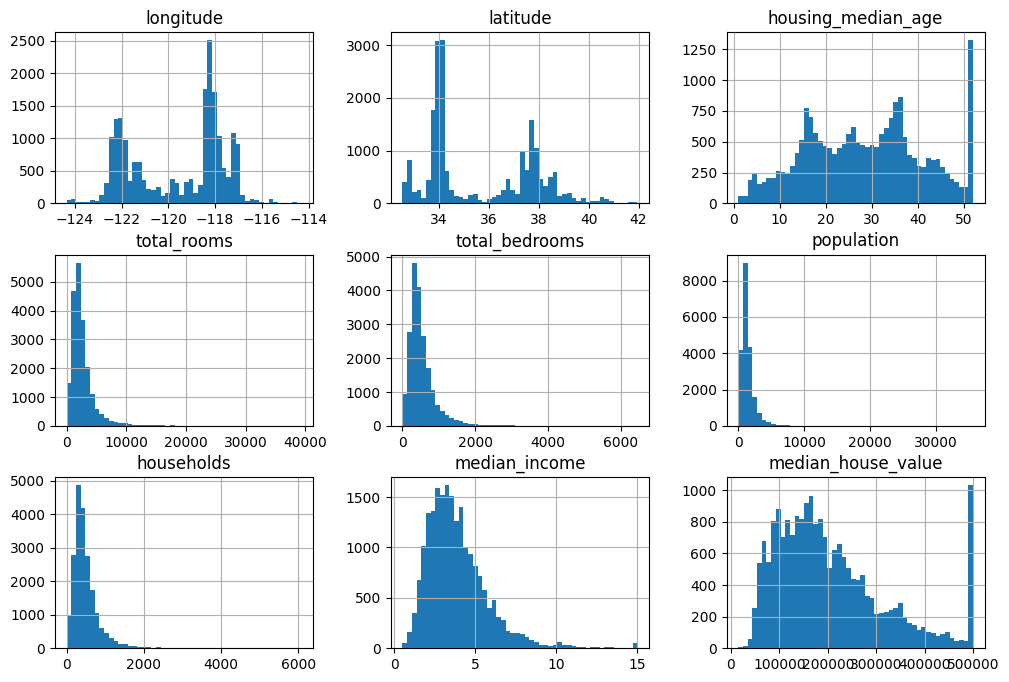

In [5]:
housing.hist(bins=50, figsize=(12,8))

## Observations from Histograms

- housing_median_age appears capped at 52.
- median_house_value appears capped around 500000.
- total_rooms, total_bedrooms, population, and households are right-skewed.
- median_income is one of the most informative-looking features and is slightly right-skewed.
- Several features may require preprocessing or transformation before model training.

In [17]:
import numpy as np 
housing["income_cat"]=np.ceil(housing["median_income"]/1.5)
housing["income_cat"]=housing["income_cat"].where(housing["income_cat"]<5,5.0)

In [18]:
housing["income_cat"].value_counts().sort_index()


income_cat
1.0     822
2.0    6581
3.0    7236
4.0    3639
5.0    2362
Name: count, dtype: int64

<Axes: >

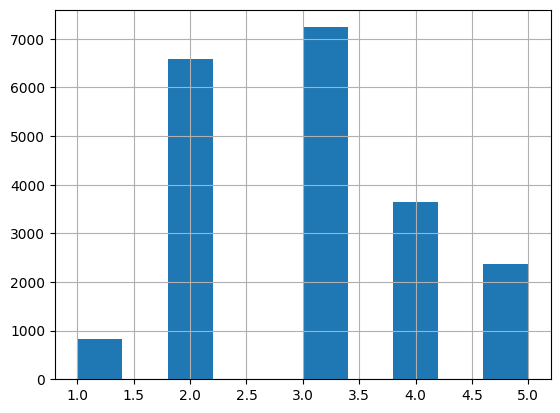

In [19]:
housing["income_cat"].hist()

# Income Categories for Stratified Sampling

## Purpose

The `median_income` feature is continuous, but stratified sampling requires discrete categories.

Therefore, income values are grouped into income categories to preserve the income distribution in both the training and test sets.

## Category Creation

- Income values are divided by 1.5 and rounded up using `ceil()`.
- This creates income groups that can be used for stratified sampling.
- All categories greater than 5 are merged into category 5.

## Why Cap at 5?

Higher income categories contain relatively few samples.

Merging them into category 5 prevents very small categories and improves the reliability of stratified sampling.

## Observations

- Five income categories were created.
- Category 3 contains the largest number of districts.
- Category 1 contains the fewest districts.
- The distribution will be used to create representative training and test sets.

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set=housing.loc[train_index]
    strat_test_set=housing.loc[test_index]

In [22]:
housing["income_cat"].value_counts()/len(housing)

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

In [23]:
strat_test_set["income_cat"].value_counts()/len(strat_test_set)

income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: count, dtype: float64

# Stratified Train-Test Split

Stratified sampling was used to create a representative train-test split based on income categories.

Since median income is strongly related to housing prices, preserving its distribution in both training and test sets reduces sampling bias.

After the split, the temporary `income_cat` column was removed to restore the dataset to its original structure.

In [24]:
exp_train=strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

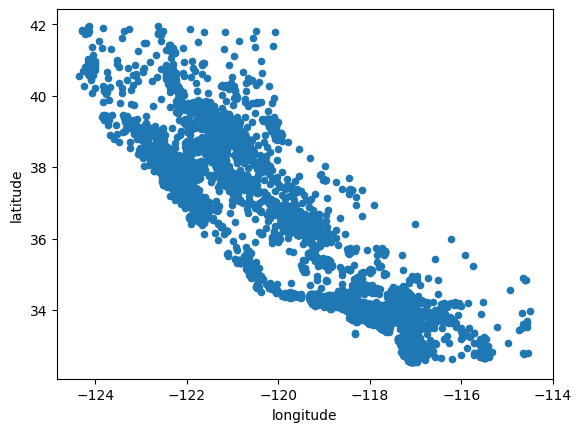

In [26]:
exp_train.plot(kind="scatter", x="longitude", y="latitude")

<Axes: xlabel='longitude', ylabel='latitude'>

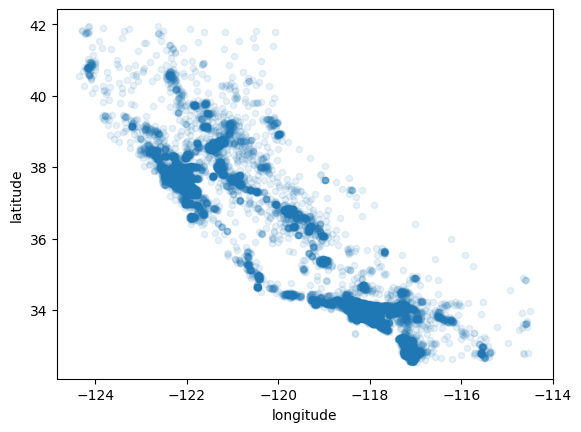

In [27]:
exp_train.plot(kind="scatter", x="longitude", y="latitude",alpha=0.1)

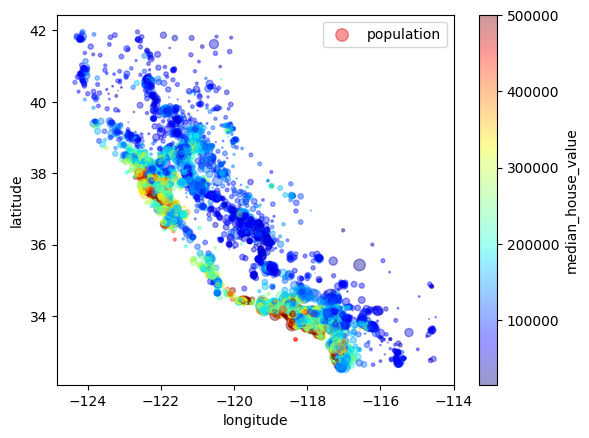

In [36]:
from matplotlib import pyplot as plt
exp_train.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
 s=exp_train["population"]/100, label="population",
 c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

## Observations from Geographic Visualization

- Higher house prices are concentrated near coastal regions.
- Inland districts generally have lower house values.
- Several highly populated coastal areas also show high house prices.
- Geographic location appears to be an important factor influencing house value.

In [38]:
corr_matrix=exp_train.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
income_cat            0.642887
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

## Correlation Analysis

- median_income has the strongest positive correlation (0.688) with median_house_value.
- income_cat also shows high correlation but was created only for stratified sampling.
- latitude has a weak negative correlation with house value.
- population shows almost no linear relationship with house value.
- Median income appears to be one of the most important predictors of housing prices.

In [39]:
exp_train["rooms_per_household"] = exp_train["total_rooms"]/exp_train["households"]
exp_train["bedrooms_per_room"]=exp_train["total_bedrooms"]/exp_train["total_rooms"]
exp_train["population_per_household"]=exp_train["population"]/exp_train["households"]

In [40]:
corr_matrix=exp_train.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688380
income_cat                  0.642887
rooms_per_household         0.143663
total_rooms                 0.137455
housing_median_age          0.102175
households                  0.071426
total_bedrooms              0.054635
population                 -0.020153
population_per_household   -0.038224
longitude                  -0.050859
latitude                   -0.139584
bedrooms_per_room          -0.256397
Name: median_house_value, dtype: float64

# Feature Engineering Observations

- rooms_per_household shows a stronger relationship with house value than total_rooms.
- bedrooms_per_room has a stronger negative correlation with house value than total_bedrooms.
- Engineered features provide more useful information than some raw features.
- Feature engineering can improve model performance by exposing hidden relationships in the data.

In [45]:
exp_train=strat_train_set.drop("median_house_value", axis=1)
exp_train_labels=strat_train_set["median_house_value"].copy()

In [46]:
exp_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY,2.0
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN,5.0
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND,2.0
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND,2.0
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN,3.0


In [48]:
exp_train_labels.head()

13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
Name: median_house_value, dtype: float64

In [49]:
exp_train.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        168
population              0
households              0
median_income           0
ocean_proximity         0
income_cat              0
dtype: int64

In [52]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")

In [53]:
exp_train_num=exp_train.drop("ocean_proximity",axis=1)
imputer.fit(exp_train_num)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','income_cat']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](9,)","[-118.51, 34.26, 29. ,..., 408. , 3.54, 3. ]"


In [54]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385,    3.    ])

# Missing Value Handling

## Problem

The `total_bedrooms` feature contains missing values.

Missing values cannot be directly processed by most machine learning algorithms and must be handled before model training.

## Approach

A `SimpleImputer` with the `median` strategy was used.

The imputer calculates the median value of each numerical feature during the `fit()` step and stores these values internally.

## Why Median?

- Median is less sensitive to outliers than the mean.
- The housing dataset contains skewed distributions and extreme values.
- Median provides a more robust estimate for missing numerical values.

## Key Learning

- `fit()` learns the replacement values from the training data.
- `transform()` applies those learned values to replace missing entries.
- Missing values should be handled using statistics learned only from the training set to avoid data leakage.

In [55]:
exp_train_cat=exp_train[["ocean_proximity"]]
exp_train_cat.head(10)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY
18031,<1H OCEAN
6753,<1H OCEAN


In [57]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder=OrdinalEncoder()
exp_train_cat_encoded=ordinal_encoder.fit_transform(exp_train_cat)
exp_train_cat_encoded[:10]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [62]:
ordinal_encoder.categories_


[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [60]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder=OneHotEncoder()
exp_train_cat_1hot=cat_encoder.fit_transform(exp_train_cat)
exp_train_cat_1hot.shape
exp_train_cat_1hot.toarray()[:5]

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [63]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

# Handling Categorical Features

## Problem

The `ocean_proximity` feature contains text-based categorical values.

Machine learning algorithms require numerical input, so categorical values must be encoded before model training.

## Ordinal Encoding

Ordinal Encoding converts each category into an integer value.

Example:

- INLAND → 0
- ISLAND → 1
- NEAR BAY → 2
- NEAR OCEAN → 3
- <1H OCEAN → 4

### Limitation

Ordinal Encoding introduces an artificial order between categories.

For example, the model may incorrectly assume:

INLAND < ISLAND < NEAR BAY < NEAR OCEAN

even though no natural ranking exists.

## One-Hot Encoding

One-Hot Encoding creates a separate binary feature for each category.

Example:

| INLAND | ISLAND | NEAR BAY |
|---------|---------|---------|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

### Benefits

- No artificial ordering
- Categories are treated independently
- Better representation for nominal categorical features

## Observations

- `ocean_proximity` is a nominal categorical feature.
- One-Hot Encoding is more appropriate than Ordinal Encoding for this feature.
- The number of encoded features equals the number of unique categories.
- Encoded categorical features can now be used by machine learning algorithms.

In [66]:
exp_train = exp_train.drop("income_cat", axis=1)
exp_train_num = exp_train.drop("ocean_proximity", axis=1)

In [67]:
exp_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='str')

In [69]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
exp_train_scaled=scaler.fit_transform(exp_train_num)
exp_train_scaled[:5]

array([[-1.42303652,  1.0136059 ,  1.86111875,  0.31191221,  1.35909429,
         0.13746004,  1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, -0.30861991, -0.43635598,
        -0.69377062, -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, -0.71224036, -0.75958421,
        -0.78876841, -0.77572662, -0.75978881],
       [ 1.23121557, -0.88492444, -0.91989094,  0.70226169,  0.73623112,
         0.38317548,  0.73137454, -0.85028088],
       [ 0.71136206, -0.87554898,  0.58980003,  0.79012465,  1.58558998,
         0.44437597,  1.75526303, -0.18036472]])

# Feature Scaling

## Problem

Numerical features in the dataset have different ranges.

Examples:

- median_income may range from 0 to 15
- population may range from 0 to tens of thousands
- total_rooms may range from hundreds to thousands

Large-scale features can dominate smaller-scale features during model training.

## Standardization

StandardScaler standardizes numerical features using the formula:

z = (x - mean) / standard_deviation

After scaling:

- Mean ≈ 0
- Standard Deviation ≈ 1

## Why Scale Features?

Feature scaling helps machine learning algorithms focus on relationships between features rather than differences in numerical magnitude.

## Algorithms That Benefit From Scaling

- Linear Regression
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)
- Neural Networks
- K-Means Clustering
- PCA

## Algorithms That Usually Do Not Require Scaling

- Decision Trees
- Random Forests
- XGBoost
- LightGBM

## Key Learning

- `fit()` calculates the mean and standard deviation from the training data.
- `transform()` applies scaling using those learned values.
- `fit_transform()` performs both operations together.
- Scaling should always be learned from the training set to avoid data leakage.

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [71]:
num_attribs = exp_train.drop("ocean_proximity", axis=1).columns.tolist()
cat_attribs = ["ocean_proximity"]

In [74]:
num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [75]:
full_pipeline=ColumnTransformer([
    ("num",num_pipeline,num_attribs),
    ("cat",OneHotEncoder(),cat_attribs)
])

In [80]:
exp_train_prepared=full_pipeline.fit_transform(exp_train)

In [81]:
exp_train_prepared.shape

(16512, 13)

# Transformation Pipeline

The preprocessing steps were combined into a reusable pipeline.

Numerical features are processed using:
- Median imputation
- Standard scaling

Categorical features are processed using:
- One-hot encoding

The full pipeline ensures that the same preprocessing logic can be applied consistently to training, validation, test, and future production data.


In [82]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(exp_train_prepared, exp_train_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-53381.26,-54311.56, 13122.77,...,198442.4 ,-43374.75,-35994.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.587e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[254.16,180.92,133.77,..., 17.92, 1.58, 0. ]"


In [83]:
some_data=exp_train.iloc[:5]
some_labels=exp_train_labels.iloc[:5]

some_data_prepared=full_pipeline.transform(some_data)

print("Prediciton: ",lin_reg.predict(some_data_prepared))
print("Labels:",list(some_labels ))


Prediciton:  [270886.93228264 334830.60618945 119856.18008898 109210.92995275
 305575.65811433]
Labels: [458300.0, 483800.0, 101700.0, 96100.0, 361800.0]


In [84]:
from sklearn.metrics import mean_squared_error
import numpy as np 
housing_predictions=lin_reg.predict(exp_train_prepared)
lin_mse=mean_squared_error(exp_train_labels,housing_predictions)
lin_rmse=np.sqrt(lin_mse)
lin_rmse

np.float64(68232.83515124217)

# Select and Train a Model

## First Model: Linear Regression

Linear Regression was used as the first baseline model.

A baseline model gives an initial performance score that can be compared with more complex models later.

## Training

The model was trained using the preprocessed training data.

The preprocessing pipeline handled:

- Missing value imputation
- Feature scaling
- One-hot encoding

## Evaluation Metric

RMSE was used to evaluate model performance because this is a regression problem.

RMSE measures the average prediction error in the same unit as the target variable.

## Observation

The initial Linear Regression model provides a baseline error.

If the RMSE is high, the model may be underfitting the data because Linear Regression is a simple model and may not capture complex patterns.

# Linear Regression Results

## RMSE

RMSE = 68,232

## Interpretation

The model's predictions differ from the actual house values by approximately $68,232 on average.

## Observation

The error remains relatively high even on the training dataset.

This suggests that Linear Regression is underfitting and may not be complex enough to capture the relationships present in the housing data.

## Next Step

Train a more powerful model and compare performance against the baseline Linear Regression model.

In [85]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)

tree_reg.fit(exp_train_prepared, exp_train_labels)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [86]:
housing_predictions = tree_reg.predict(exp_train_prepared)

tree_mse = mean_squared_error(
    exp_train_labels,
    housing_predictions
)

tree_rmse = np.sqrt(tree_mse)

tree_rmse

np.float64(0.0)

# Decision Tree Regression

## Training RMSE

RMSE = 0.0

## Observation

The model achieves perfect performance on the training data.

However, this does not necessarily indicate a good model.

Decision Trees are highly flexible and can memorize training examples, leading to overfitting.

## Key Learning

Training performance alone is not sufficient to evaluate a model.

The model must be evaluated on unseen data using cross-validation or a validation set.